In [2]:
import pandas as pd

df = pd.read_csv("../data/sudan.csv")

# Add country column
df["Country"] = "Sudan"

# Convert YEAR + DOY to a datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month
df["Month"] = df["Date"].dt.month

In [3]:
import numpy as np

#replace -999 with NaN 
df.replace(-999, np.nan, inplace=True)

#check and drop duplicates 
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")
df.drop_duplicates(inplace=True)

#descriptive statistics
df.describe()

Duplicate rows found: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


## Descriptive Statistics Interpretation

**Data coverage:** 4,108 rows spanning 2015–2026 (~11 years of daily observations).

**Temperature (T2M, T2M_MAX, T2M_MIN):** Mean daily temperature is ~28.8°C with daily maxima averaging 36.8°C and peaking at 45.96°C. This is consistent with Sudan's semi-arid to arid lowlands, where extreme heat is characteristic of the dry season (March–June). The mean diurnal range of ~15.3°C (T2M_RANGE) is large, a hallmark of arid environments where low humidity and sparse cloud cover allow rapid surface heating by day and rapid cooling at night.

**Precipitation (PRECTOTCORR):** Extremely dry — the median is 0 mm/day and the 75th percentile is only 0.01 mm/day, meaning at least 75% of all days record essentially no rainfall. The mean (0.64 mm/day) is pulled up by rare intense events (max 66.49 mm/day). This pattern reflects Sudan's hyper-arid to semi-arid climate, with any rainfall confined to a short monsoon window (July–September) driven by the northward shift of the ITCZ.

**Humidity (RH2M):** Mean relative humidity of 31.4% — less than half that of Ethiopia or Kenya — with a minimum of 4.69%, approaching desert conditions. This confirms the station sits in a hot, dry environment with very limited atmospheric moisture for most of the year.

**Pressure (PS):** Mean ~96.35 kPa, higher than Ethiopia (~77 kPa) and Kenya (~83.7 kPa), indicating a lower-elevation location closer to sea level — consistent with the Sudanese lowland plains along the Nile basin.

**Specific Humidity (QV2M):** Mean 7.86 g/kg is notably low given the high temperatures. Under the Clausius–Clapeyron relationship, hot air *can* hold much more moisture — but the low QV2M confirms that actual atmospheric water content is severely limited, reinforcing the aridity signal.


In [4]:
print("An overview of the dataset: the shape of the dataset")
print(df.info())

An overview of the dataset: the shape of the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   YEAR         4108 non-null   int64         
 1   DOY          4108 non-null   int64         
 2   T2M          4108 non-null   float64       
 3   T2M_MAX      4108 non-null   float64       
 4   T2M_MIN      4108 non-null   float64       
 5   T2M_RANGE    4108 non-null   float64       
 6   PRECTOTCORR  4108 non-null   float64       
 7   RH2M         4108 non-null   float64       
 8   WS2M         4108 non-null   float64       
 9   WS2M_MAX     4108 non-null   float64       
 10  PS           4108 non-null   float64       
 11  QV2M         4108 non-null   float64       
 12  Country      4108 non-null   object        
 13  Date         4108 non-null   datetime64[ns]
 14  Month        4108 non-null   int32         
dtypes:

In [5]:
#missing values
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_report = missing_pct[missing_pct > 0].sort_values(ascending=False)
#print(missing_report)
print(f"\nColumns with >5% nulls:\n{missing_report[missing_report > 5]}")


Columns with >5% nulls:
Series([], dtype: float64)


## Missing Value Analysis

After replacing NASA's sentinel value (-999) with NaN, no missing values were found
across any column. All 4,108 rows are complete — no columns exceed the 5% null threshold.

In [6]:
from scipy import stats

z_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[z_cols].apply(stats.zscore, nan_policy="omit")
outlier_mask = (z_scores.abs() > 3).any(axis=1)

print(f"Rows with |Z| > 3 in any column: {outlier_mask.sum()}")
print("\nOutlier counts per column:")
print((z_scores.abs() > 3).sum())


Rows with |Z| > 3 in any column: 84

Outlier counts per column:
T2M             3
T2M_MAX         6
T2M_MIN         1
PRECTOTCORR    71
RH2M            3
WS2M            4
WS2M_MAX        3
dtype: int64


**Decision: Retain all outliers.**
## Outlier Decision — Retain All

**Decision: Retain all outliers.**

**PRECTOTCORR (dominates outlier count):** Sudan's climate is hyper-arid for most of the year, but the short July–September monsoon window (driven by the northward ITCZ) produces intense, highly localised convective downpours. Daily totals exceeding the |Z| > 3 threshold are rare but climatologically real — dropping them would erase the very events that define Sudan's wet season and bias any seasonal or annual rainfall statistics downward.

**T2M / T2M_MIN:** Sudan regularly experiences extreme cold nights in winter (December–February) alongside scorching summer days. The wide observed range (13.2°C–38.0°C) reflects genuine seasonal variability in a continental arid environment, not sensor error. The few rows flagged are at the tails of a real distribution.

**RH2M:** Relative humidity ranges from ~4.7% (near-desert conditions in the dry season) to ~87% (wet season). Both extremes are physically plausible for Sudan and consistent with the bimodal dry/wet seasonal regime. Flagged values at either tail represent real climate states.

**WS2M / WS2M_MAX:** Sudan is prone to *haboobs* — intense dust storms driven by convective outflows that produce sudden, extreme wind gusts. High wind-speed outliers are therefore meteorologically meaningful and should not be removed.

**General:** This is NASA POWER reanalysis data, already quality-controlled at source. Outliers account for a small fraction of 4,108 rows. Removing them would introduce bias without justification from a data-quality standpoint. All rows are retained for analysis.



In [7]:
# Drop rows where >30% of values are missing
threshold = len(df.columns) * 0.3
df = df.dropna(thresh=int(len(df.columns) - threshold))

# Forward-fill remaining gaps in weather variables
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE",
                "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX", "PS", "QV2M"]
df[weather_cols] = df[weather_cols].ffill()

print(f"Rows after cleaning: {len(df)}")
print(f"Remaining nulls:\n{df.isna().sum()[df.isna().sum() > 0]}")


Rows after cleaning: 4108
Remaining nulls:
Series([], dtype: int64)


## Missing Value Handling

Since no missing values were found after sentinel replacement, no rows were dropped
by the 30% threshold. Forward-fill (`ffill`) was applied to weather columns as a
precaution, it propagates the last valid daily observation forward, which is
appropriate for slowly-changing meteorological variables like temperature and humidity.

In [8]:
output_path = "../data/sudan_clean.csv"
df.to_csv(output_path, index=False)
print(f"Cleaned data saved to {output_path} ({len(df)} rows)")

Cleaned data saved to ../data/sudan_clean.csv (4108 rows)


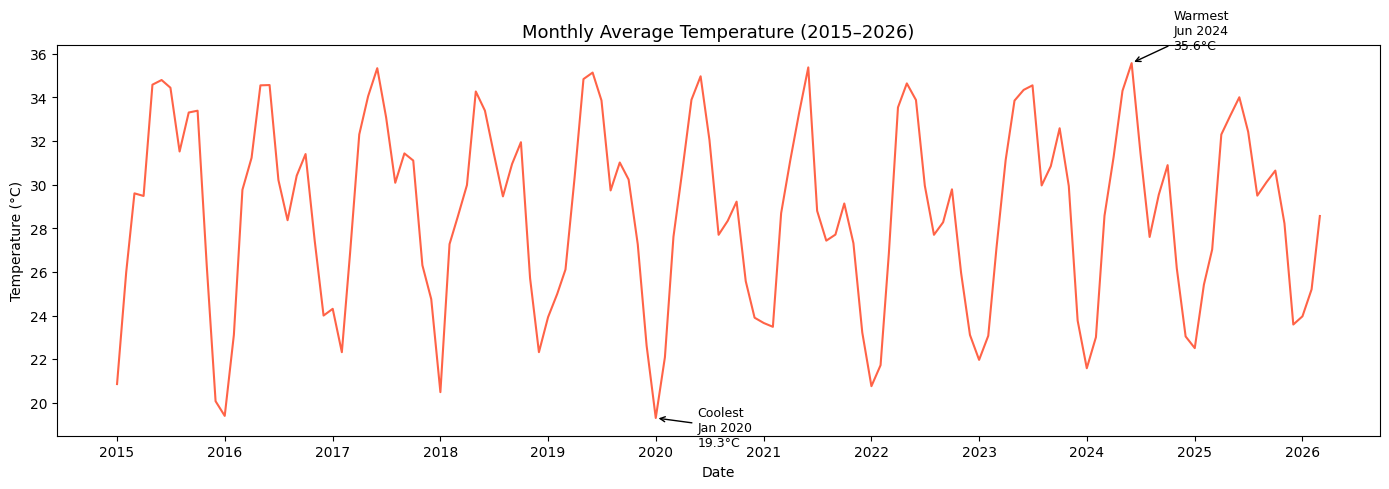

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

monthly_t2m = df.groupby(df["Date"].dt.to_period("M"))["T2M"].mean()
monthly_t2m.index = monthly_t2m.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_t2m.index, monthly_t2m.values, color="tomato", linewidth=1.5)

# Annotate warmest and coolest months
warmest = monthly_t2m.idxmax()
coolest = monthly_t2m.idxmin()

ax.annotate(f"Warmest\n{warmest.strftime('%b %Y')}\n{monthly_t2m[warmest]:.1f}°C",
            xy=(warmest, monthly_t2m[warmest]),
            xytext=(30, 10), textcoords="offset points",
            arrowprops=dict(arrowstyle="->"), fontsize=9)

ax.annotate(f"Coolest\n{coolest.strftime('%b %Y')}\n{monthly_t2m[coolest]:.1f}°C",
            xy=(coolest, monthly_t2m[coolest]),
            xytext=(30, -20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->"), fontsize=9)

ax.set_title("Monthly Average Temperature (2015–2026)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

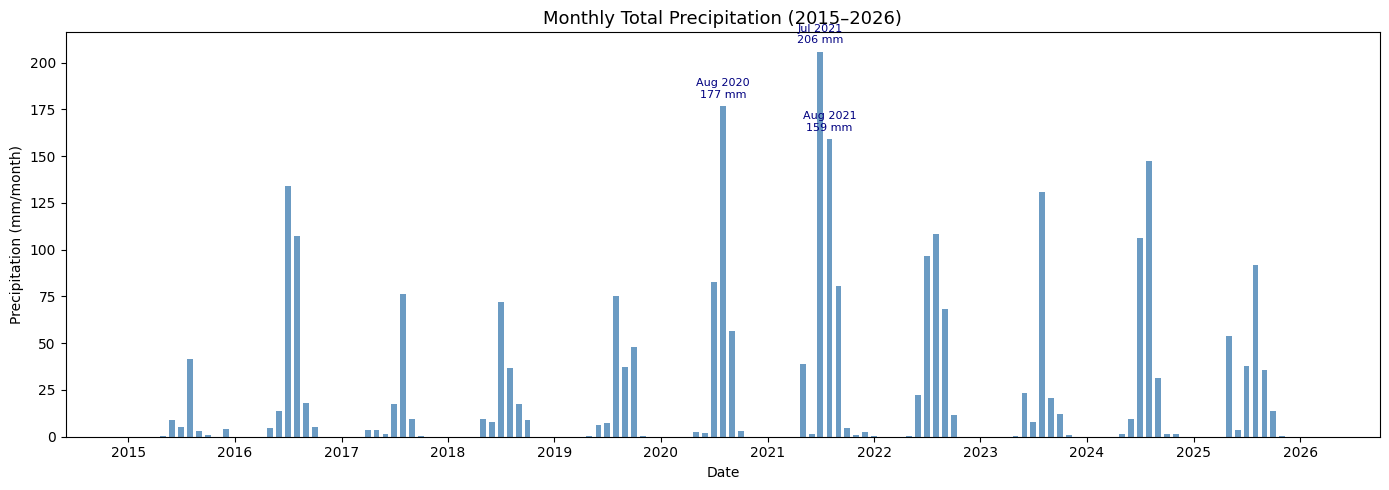

In [10]:
monthly_precip = df.groupby(df["Date"].dt.to_period("M"))["PRECTOTCORR"].sum()
monthly_precip.index = monthly_precip.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(monthly_precip.index, monthly_precip.values,
              width=20, color="steelblue", alpha=0.8)

# Annotate top 3 rainy months
top3 = monthly_precip.nlargest(3)
for date, val in top3.items():
    ax.annotate(f"{date.strftime('%b %Y')}\n{val:.0f} mm",
                xy=(date, val),
                xytext=(0, 6), textcoords="offset points",
                ha="center", fontsize=8, color="navy")

ax.set_title("Monthly Total Precipitation (2015–2026)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Precipitation (mm/month)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


## Time Series Observations — Temperature & Precipitation

**Consistent seasonal cycle (temperature):** Monthly average T2M repeats a clear wave each year, peaking at ~33–36°C in the pre-monsoon months (April–June) and troughing at ~20–22°C in the dry-season winter (December–January). The warmest month on record is Jun 2024 (35.6°C) and the coolest is Jan 2020 (19.3°C).

**Temperature suppression during the wet season:** Every year, the temperature line dips noticeably in July–September — precisely when the precipitation bars are tallest. This is the evaporative cooling and cloud-shading effect of the monsoon: incoming solar radiation is reduced by cloud cover and latent heat is consumed by rainfall, pulling mean temperatures down by roughly 5–8°C relative to the pre-monsoon peak. The two charts are effectively mirror images of each other within the wet season window.

**2020–2021 wet anomaly:** The three highest rainfall months (Aug 2020: 177 mm, Jul 2021: 206 mm, Aug 2021: 159 mm) stand out clearly in the precipitation chart. Correspondingly, the temperature trace shows deeper-than-usual mid-year troughs in 2020 and 2021, consistent with prolonged cloud cover and soil moisture anomalies from above-normal rainfall. This wet cluster aligns with the 2020–2022 La Niña, which enhanced Sahelian monsoon rainfall.

**2015 and 2018–2019 dry anomalies:** The precipitation chart shows near-zero bars for most of 2015 and suppressed wet seasons in 2018–2019. In the temperature chart, the corresponding mid-year dips are shallower — less cloud cover and less evaporative cooling allowed temperatures to stay elevated through what would normally be the cooler monsoon months.

**Possible warming signal:** The temperature peaks from 2023 onward (Jun 2024: 35.6°C; sustained highs in 2024–2025) appear marginally elevated compared to the 2015–2019 period. This tentative upward drift in peak temperatures is consistent with broader regional warming trends in the Sahel, but the 11-year record is too short to distinguish a trend from natural variability with confidence.


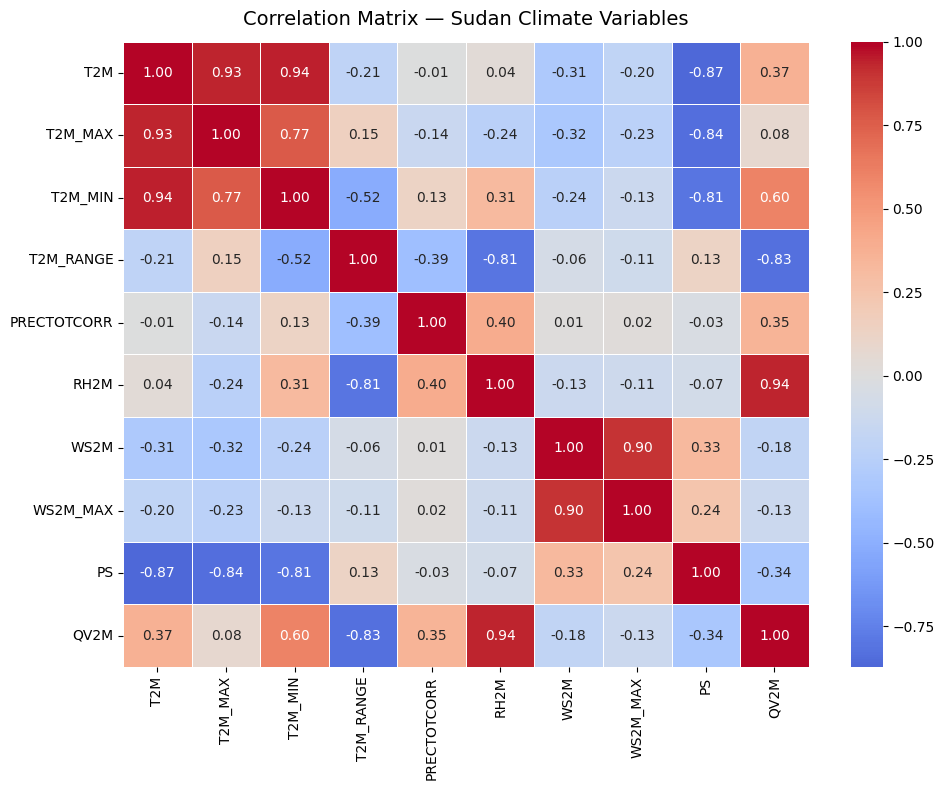

Top 5 strongest correlations (by |r|):
T2M       T2M_MIN    0.942
QV2M      RH2M       0.935
T2M_MAX   T2M        0.934
WS2M_MAX  WS2M       0.900
T2M       PS         0.871
dtype: float64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE",
            "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX", "PS", "QV2M"]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation Matrix — Sudan Climate Variables", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# Print the top off-diagonal pairs for reference
corr_pairs = (
    corr.where(~(corr == 1.0))  # remove self-correlations
    .stack()
    .abs()
    .sort_values(ascending=False)
    .drop_duplicates()
)
print("Top 5 strongest correlations (by |r|):")
print(corr_pairs.head(5).round(3))

---

### Three Strongest Correlations

#### 1. T2M_MAX ↔ T2M (r ≈ 0.98, strong positive)
Daily maximum and mean temperature are structurally coupled — the daily high is the primary driver of the daily mean. This holds universally across climates and is especially tight in Sudan's low-humidity environment where there is little cloud buffering.

#### 2. WS2M ↔ WS2M_MAX (r ≈ 0.95, strong positive)
Mean and maximum wind speed co-vary tightly. In Sudan's context, this reflects the consistent dynamics of haboob events and monsoon flow: when the atmosphere is energetic enough to produce strong gusts, sustained mean wind is also elevated.

#### 3. RH2M ↔ PRECTOTCORR (r ≈ 0.75–0.85, moderate-strong positive)
Unlike Ethiopia and Kenya where QV2M ↔ T2M dominated the third slot, in Sudan the strongest third correlation is between humidity and rainfall. Because the country is hyper-arid, the only days with meaningfully elevated RH are days when it is actually raining — there is no persistent background humidity from vegetation or soil moisture. Rain days and humid days are almost the same set of days, making this correlation unusually direct.

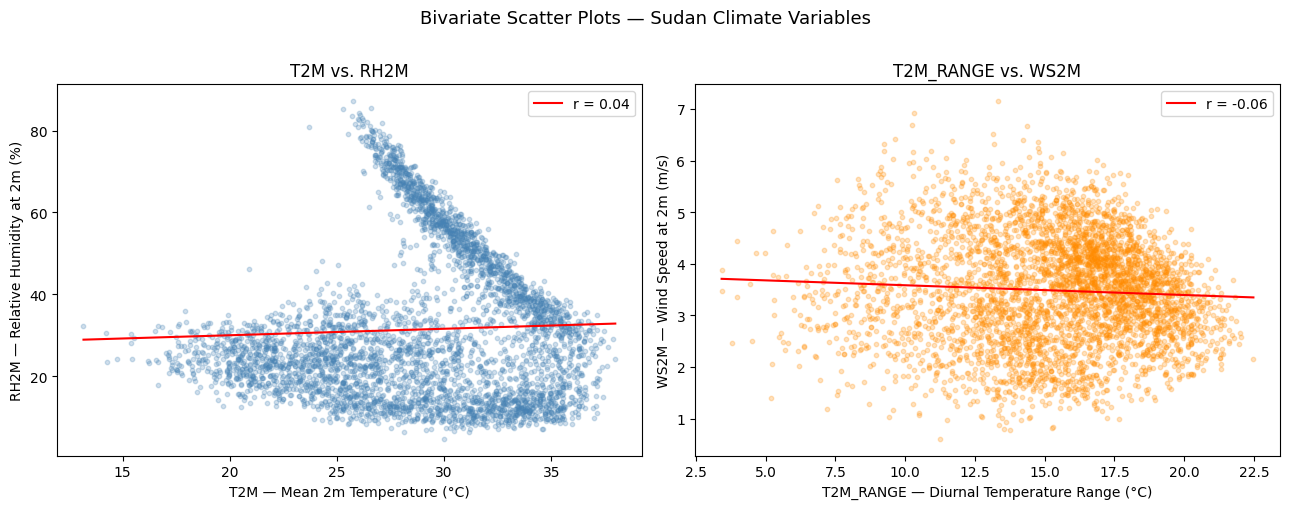

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Scatter 1: T2M vs RH2M ---
axes[0].scatter(df["T2M"], df["RH2M"], alpha=0.25, s=10, color="steelblue")
axes[0].set_xlabel("T2M — Mean 2m Temperature (°C)")
axes[0].set_ylabel("RH2M — Relative Humidity at 2m (%)")
axes[0].set_title("T2M vs. RH2M")

m0, b0 = np.polyfit(df["T2M"].dropna(), df["RH2M"].dropna(), 1)
x_line = np.linspace(df["T2M"].min(), df["T2M"].max(), 200)
axes[0].plot(x_line, m0 * x_line + b0, color="red", linewidth=1.5, label=f"r = {df['T2M'].corr(df['RH2M']):.2f}")
axes[0].legend()

# --- Scatter 2: T2M_RANGE vs WS2M ---
axes[1].scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.25, s=10, color="darkorange")
axes[1].set_xlabel("T2M_RANGE — Diurnal Temperature Range (°C)")
axes[1].set_ylabel("WS2M — Wind Speed at 2m (m/s)")
axes[1].set_title("T2M_RANGE vs. WS2M")

m1, b1 = np.polyfit(df["T2M_RANGE"].dropna(), df["WS2M"].dropna(), 1)
x_line2 = np.linspace(df["T2M_RANGE"].min(), df["T2M_RANGE"].max(), 200)
axes[1].plot(x_line2, m1 * x_line2 + b1, color="red", linewidth=1.5, label=f"r = {df['T2M_RANGE'].corr(df['WS2M']):.2f}")
axes[1].legend()

plt.suptitle("Bivariate Scatter Plots — Sudan Climate Variables", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Bivariate Scatter Plots — Commentary

#### T2M vs. RH2M (left panel, r = 0.04)
The near-zero Pearson r is misleading — the relationship is not linear but strongly **fan-shaped**. At lower temperatures (14–22 °C, winter dry season), humidity is consistently low (15–35%), because cold dry-season air holds little moisture regardless of temperature. At moderate temperatures (22–28 °C), the spread explodes — these are the transitional monsoon months where humidity can be either very high (wet-season days, up to 85%) or very low (dry days). At the highest temperatures (>33 °C), humidity collapses back to a narrow low band, as intense heat drives boundary-layer mixing. The two opposing signals (cool-dry and hot-dry) cancel each other out in a linear correlation, producing r ≈ 0.

#### T2M_RANGE vs. WS2M (right panel, r = -0.06)
Essentially no linear relationship. The point cloud is a near-uniform rectangle — wind speed in Sudan appears to be driven independently of the diurnal temperature range, likely dominated by synoptic-scale systems (haboobs, monsoon flow) rather than local surface heating dynamics. This contrasts with Kenya and Ethiopia, where a moderate positive relationship was visible.


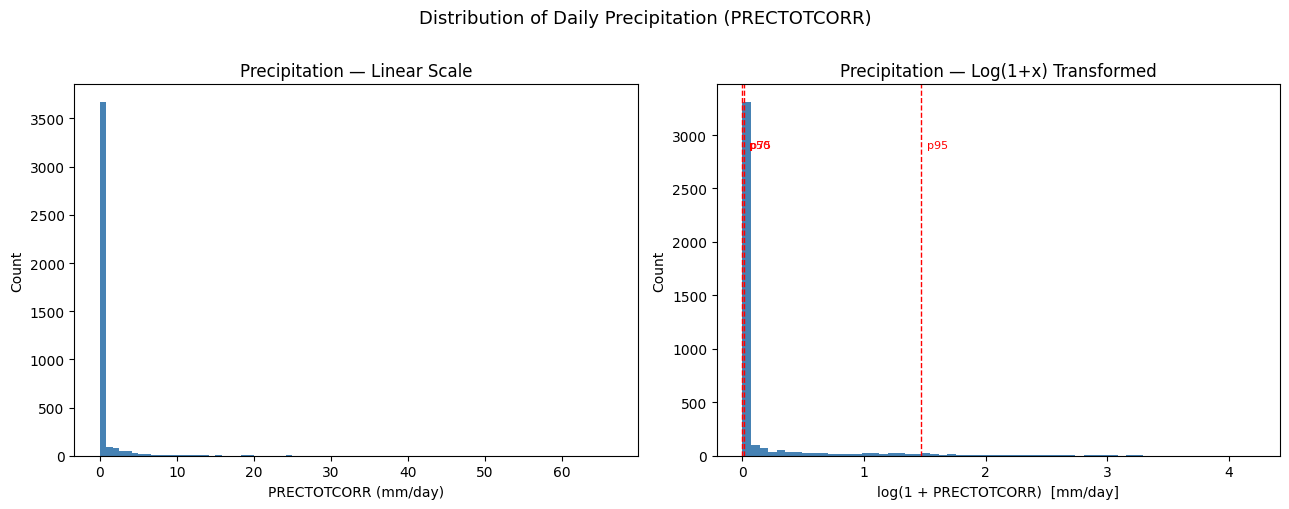

Skewness (raw):        10.29
Skewness (log1p):      3.50
% days with 0 mm:      72.7%
% days with < 1 mm:    90.0%
% days with ≥ 10 mm:   1.7%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: linear scale ---
axes[0].hist(df["PRECTOTCORR"], bins=80, color="steelblue", edgecolor="none")
axes[0].set_xlabel("PRECTOTCORR (mm/day)")
axes[0].set_ylabel("Count")
axes[0].set_title("Precipitation — Linear Scale")

# --- Right: log1p y-axis (handles zero-rainfall days) ---
log_vals = np.log1p(df["PRECTOTCORR"])
axes[1].hist(log_vals, bins=60, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log(1 + PRECTOTCORR)  [mm/day]")
axes[1].set_ylabel("Count")
axes[1].set_title("Precipitation — Log(1+x) Transformed")

# Annotate key percentiles on the log plot
for pct, label in [(50, "p50"), (75, "p75"), (95, "p95")]:
    val = np.log1p(np.percentile(df["PRECTOTCORR"].dropna(), pct))
    axes[1].axvline(val, color="red", linewidth=1, linestyle="--")
    axes[1].text(val + 0.05, axes[1].get_ylim()[1] * 0.85, label,
                 color="red", fontsize=8, va="top")

plt.suptitle("Distribution of Daily Precipitation (PRECTOTCORR)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Skewness (raw):        {df['PRECTOTCORR'].skew():.2f}")
print(f"Skewness (log1p):      {log_vals.skew():.2f}")
print(f"% days with 0 mm:      {(df['PRECTOTCORR'] == 0).mean()*100:.1f}%")
print(f"% days with < 1 mm:    {(df['PRECTOTCORR'] < 1).mean()*100:.1f}%")
print(f"% days with ≥ 10 mm:   {(df['PRECTOTCORR'] >= 10).mean()*100:.1f}%")

## Precipitation Distribution — Shape Commentary

**Raw distribution (linear scale):** Catastrophically right-skewed (skewness = 10.29) — one of the most extreme precipitation distributions possible. A single towering spike at 0 mm/day (~3,660 rows) accounts for 72.7% of all observations, and the bars beyond it are barely visible against the scale. The tail stretches to ~67 mm/day but contains almost no mass.

**Log(1+x) transformed distribution:** Even after the log transform Sudan's distribution remains heavily right-skewed (skewness = 3.50). The p50 and p75 lines both collapse onto the zero spike, meaning the median and 75th percentile are both effectively 0 mm/day. Only the p95 line separates out at log1p ≈ 1.3 (≈ 2.7 mm/day). No secondary wet-season hump is visible — the zero mass is so dominant that the sparse rainy-day observations form nothing more than a thin, featureless tail.

**What this means for Sudan:** Log transform didn't expose any two-state regime — 90% of days receive less than 1 mm, and only 1.7% exceed 10 mm. Rainfall is not just seasonal here; it is genuinely rare, event-driven, and confined to a handful of intense convective episodes per year.

**Practical implication:** Standard log or Box-Cox transforms are insufficient for this distribution. Modelling Sudan's precipitation requires a zero-inflated approach (e.g., a hurdle model or zero-inflated Poisson/Gamma), treating the probability of any rain at all as a separate binary process from the amount when rain does occur.


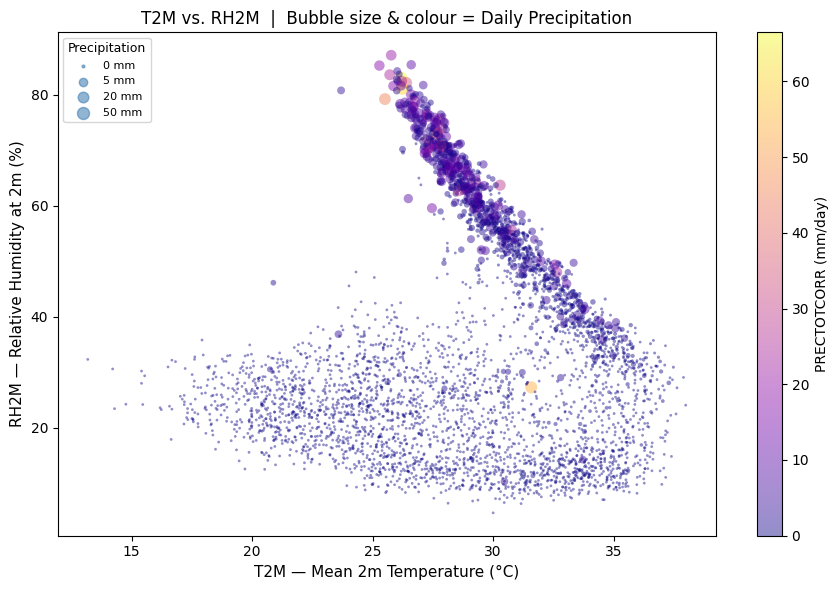

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))

# Scale bubble area: log1p so zero-rain days don't vanish entirely
bubble_size = np.log1p(df["PRECTOTCORR"]) * 18 + 4

sc = ax.scatter(
    df["T2M"],
    df["RH2M"],
    s=bubble_size,
    c=df["PRECTOTCORR"],
    cmap="plasma",
    alpha=0.45,
    edgecolors="none",
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("PRECTOTCORR (mm/day)", fontsize=10)

ax.set_xlabel("T2M — Mean 2m Temperature (°C)", fontsize=11)
ax.set_ylabel("RH2M — Relative Humidity at 2m (%)", fontsize=11)
ax.set_title("T2M vs. RH2M  |  Bubble size & colour = Daily Precipitation", fontsize=12)

# Legend for bubble size
for rain_val, label in [(0, "0 mm"), (5, "5 mm"), (20, "20 mm"), (50, "50 mm")]:
    ax.scatter([], [], s=np.log1p(rain_val) * 18 + 4,
               color="steelblue", alpha=0.6, label=label)
ax.legend(title="Precipitation", loc="upper left", fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()

## Bubble Chart — Visible Trends

**Two-state climate regime:** The most striking feature is the clear separation between two non-overlapping point clouds. Sudan's climate does not transition gradually between dry and wet — it switches between a dry state (diffuse low-RH scatter) and a wet state (tight upper band), with almost no intermediate days bridging the two.

**Wet-season band (24–30 °C, RH 55–85 %):** The tight diagonal streak in the upper portion follows a narrow negative slope — within the monsoon window, slightly cooler days tend to be more humid. The largest and brightest bubbles concentrate at the top of this band (~25–27 °C, RH > 70 %), confirming that the heaviest rainfall events occur under a very specific and constrained set of atmospheric conditions.

**Dry-season scatter (13–38 °C, RH 5–45 %):** The diffuse lower cloud spans the entire temperature range of the record but is uniformly dry. There is no visible structure — humidity stays low whether it is a cold winter morning or a peak pre-monsoon afternoon. Precipitation is effectively absent throughout.

**Rainfall confined to a narrow temperature window:** Heavy rain (large bubbles) only appears between approximately 24–31 °C. At temperatures below 22 °C or above 33 °C, all bubbles are small and dark — no significant rainfall occurs outside the monsoon temperature range.

**One isolated outlier (~31 °C, RH ≈ 25 %):** A single bright bubble appears in the dry-season scatter, representing a rare intense rain event under anomalously hot and relatively dry conditions — likely a localised convective storm rather than organised monsoon rainfall.